## imports

In [24]:
from astroquery.mast import Observations
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval
import astropy.units as u

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs

import numpy as np

## An Aside Running a MAST Query

we want to search MAST.

here are a few common parameters you may want to use when searching MAST:

| Criterion | Meaning |
|--|--|
|`object_name`| The name of the celestial object: this name will be resolved to coordinates|
|`target_name`| The name of the celestial object **as entered by the proposer**|
|`obs_collection`| Roughly equivalent to mission |

Searching by `object_name` will tend to be a slow filter, since the API must:
1. Query a resolver service (likely Simbad or NED) to transform your input into coordinates
2. Look for observations with a spatial match on your input. This is no small task when the database has over 500 million rows!

TO-DO: talk about setting the resolver manually


Let's run an example query:

In [4]:
obs = Observations.query_criteria(
    object_name="Trappist-1",
    obs_collection="JWST"
    )

len(obs)

405

Lots of observations. Let's take a look at what the proposers called the targets:

In [5]:
set(obs['target_name'])

{np.str_('TRAPPIST-1'), np.str_('TRAPPIST-1B'), np.str_('UNKNOWN')}

These results highlight the pitfalls of searching by target name. Sometimes an observer may use a non-standard name, or a the name might not be populated in the database at all!

You can sometimes get around this with wildcard characters:

TO-DO: repeat the above but with `target_name` and a wildcard character. {show an example of a wildcard match before, just in text}

In [6]:
obs = Observations.query_criteria(
    target_name="Trappist*",
    obs_collection="JWST"
    )

len(obs)

388

TO-DO: very fast but we're missing 17 observations

## Narrowing in on Our Brick

If we're careful, we can take advantage of the `target_name` trick for very fast searching.

In [7]:
obs = \
Observations.query_criteria(
    target_name="M31-B01-F*-UVIS",
    wave_region="UV",
    proposal_id=12058,
    project="HST"
                           )

In [8]:
obs

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max
str7,str3,str6,str9,str3,str5,str2,str16,str49,str9,float64,float64,str5,str19,int64,float64,float64,float64,str2,float64,float64,str44,float64,str5,str2,int64,str275,str34,str35,str6,bool,float64,str8,str10,float64,float64
science,HST,CALWF3,WFC3/UVIS,HST,F275W,UV,M31-B01-F01-UVIS,GALAXY;DISK;SPIRAL;SPIRAL ARM;STAR FORMING REGION,ibf301040,10.84988779557,41.25507836507,image,"Dalcanton, Julianne",3,55544.18725231481,55544.21188174769,1010.0,UV,243.20000000000002,305.8,A Panchromatic Hubble Andromeda Treasury - I,55544.57085634,12058,GO,--,POLYGON 10.83608018 41.2352132 10.836732796581748 41.234997161307909 10.83671075 41.23496512 10.86431577 41.22582217 10.89205254 41.26607946 10.891399946792911 41.26629576221967 10.89142207 41.26632785 10.86380354 41.27547728 10.83608018 41.2352132 10.83608018 41.2352132,mast:HST/product/ibf301040_drz.jpg,mast:HST/product/ibf301040_drz.fits,PUBLIC,False,nan,24799697,921422302,243.20000000000002,305.8
science,HST,CALWF3,WFC3/UVIS,HST,F275W,UV,M31-B01-F02-UVIS,GALAXY;DISK;SPIRAL;SPIRAL ARM;STAR FORMING REGION,ibf302040,10.80978721863,41.26850058728,image,"Dalcanton, Julianne",3,55546.667657488426,55546.692286921294,1010.0,UV,243.20000000000002,305.8,A Panchromatic Hubble Andromeda Treasury - I,55547.04094899,12058,GO,--,POLYGON 10.79597674 41.24863542 10.796629515606503 41.248419373326158 10.79660747 41.24838734 10.82421816 41.23924439 10.85196063 41.27950168 10.851307926707046 41.279717974274469 10.85133006 41.27975007 10.82370585 41.2888995 10.79597674 41.24863542 10.79597674 41.24863542,mast:HST/product/ibf302040_drz.jpg,mast:HST/product/ibf302040_drz.fits,PUBLIC,False,nan,24799700,1128182226,243.20000000000002,305.8
science,HST,CALWF3,WFC3/UVIS,HST,F275W,UV,M31-B01-F04-UVIS,GALAXY;DISK;SPIRAL;SPIRAL ARM;STAR FORMING REGION,ibf304040,10.72620393816,41.29516606578,image,"Dalcanton, Julianne",3,55399.88604563657,55399.90853394676,925.0,UV,243.20000000000002,305.8,A Panchromatic Hubble Andromeda Treasury - I,55400.08483794,12058,GO,--,POLYGON 10.68403585 41.28416238 10.684690197797215 41.283946140314711 10.68465897 41.28390075 10.71228905 41.27476518 10.74002762 41.31502988 10.739373278170291 41.315246390572518 10.73940461 41.31529184 10.71176097 41.32443388 10.68403585 41.28416238 10.68403585 41.28416238,mast:HST/product/ibf304040_drz.jpg,mast:HST/product/ibf304040_drz.fits,PUBLIC,False,nan,24799706,921422177,243.20000000000002,305.8
science,HST,CALWF3,WFC3/UVIS,HST,F275W,UV,M31-B01-F03-UVIS,GALAXY;DISK;SPIRAL;SPIRAL ARM;STAR FORMING REGION,ibf303040,10.76968705854,41.2819228095,image,"Dalcanton, Julianne",3,55548.019659722224,55548.06791172454,1010.0,UV,243.20000000000002,305.8,A Panchromatic Hubble Andromeda Treasury - I,55548.18656248,12058,GO,--,POLYGON 10.75587374 41.26205764 10.756526650110121 41.261841593304133 10.7565046 41.26180956 10.78412097 41.25266661 10.81186915 41.2929239 10.81121631232682 41.293140194539447 10.81123845 41.29317229 10.78360855 41.30232172 10.75587374 41.26205764 10.75587374 41.26205764,mast:HST/product/ibf303040_drz.jpg,mast:HST/product/ibf303040_drz.fits,PUBLIC,False,nan,24799703,921422267,243.20000000000002,305.8
science,HST,CALWF3,WFC3/UVIS,HST,F275W,UV,M31-B01-F03-UVIS,GALAXY;DISK;SPIRAL;SPIRAL ARM;STAR FORMING REGION,ibf319030,10.76968705854,41.2819228095,image,"Dalcanton, Julianne",3,55564.587333414354,55564.64737951389,1010.0,UV,243.20000000000002,305.8,A Panchromatic Hubble Andromeda Treasury - I,55564.765162,12058,GO,--,POLYGON 10.75587374 41.26205764 10.756526650110121 41.261841593304133 10.7565046 41.26180956 10.78412097 41.25266661 10.81186915 41.2929239 10.81121631232682 41.29

In [9]:
prod = Observations.get_product_list(obs)

In [10]:
prod

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str8,str3,str5,str37,str64,str1,str97,str9,str28,str11,str1,str7,str19,str5,str52,int64,str8,str6,int64,str9
25438496,HLA,image,hst_12058_01_wfc3_uvis_f275w_01,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_12058_01_wfc3_uvis_f275w_01,PREVIEW,--,--,--,HLA,--,12058,hst_12058_01_wfc3_uvis_f275w_01_drz.jpg,--,24799697,PUBLIC,2,F275W
25438496,HLA,image,hst_12058_01_wfc3_uvis_f275w_01,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_12058_01_wfc3_uvis_f275w_01_drz.fits,SCIENCE,--,DRZ,--,HLA,--,12058,hst_12058_01_wfc3_uvis_f275w_01_drz.fits,127771200,24799697,PUBLIC,2,F275W
25438497,HLA,image,hst_12058_01_wfc3_uvis_f275w_02,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_12058_01_wfc3_uvis_f275w_02,PREVIEW,--,--,--,HLA,--,12058,hst_12058_01_wfc3_uvis_f275w_02_drz.jpg,--,24799697,PUBLIC,2,F275W
25438497,HLA,image,hst_12058_01_wfc3_uvis_f275w_02,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_12058_01_wfc3_uvis_f275w_02_drz.fits,SCIENCE,--,DRZ,--,HLA,--,12058,hst_12058_01_wfc3_uvis_f275w_02_drz.fits,127771200,24799697,PUBLIC,2,F275W
25438514,HLA,image,hst_12058_02_wfc3_uvis_f275w_01,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_12058_02_wfc3_uvis_f275w_01,PREVIEW,--,--,--,HLA,--,12058,hst_12058_02_wfc3_uvis_f275w_01_drz.jpg,--,24799700,PUBLIC,2,F275W
25438514,HLA,image,hst_12058_02_wfc3_uvis_f275w_01,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_12058_02_wfc3_uvis_f275w_01_drz.fits,SCIENCE,--,DRZ,--,HLA,--,12058,hst_12058_02_wfc3_uvis_f275w_01_drz.fits,127771200,24799700,PUBLIC,2,F275W
25438515,HLA,image,hst_12058_02_wfc3_uvis_f275w_02,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_12058_02_wfc3_uvis_f275w_02,PREVIEW,--,--,--,HLA,--,12058,hst_12058_02_wfc3_uvis_f275w_02_drz.jpg,--,24799700,PUBLIC,2,F275W
25438515,HLA,image,hst_12058_02_wfc3_uvis_f275w_02,HLA simple fits science image,S,mast:HLA/url/cgi-bin/getdata.cgi?dataset=hst_12058_02_wfc3_uvis_f275w_02_drz.fits,SCIENCE,--,DRZ,--,HLA,--,12058,hst_12058_02_wfc3_uvis_f275w_02_drz.fits,127771200,24799700,PUBLIC,2,F275W
25438538,HLA,image,hst_12058_04_wfc3_uvis_f275w_01,Preview-Full,S,mast:HLA/url/cgi-bin/preview.cgi?dataset=hst_12058_04_wfc3_uvis_f275w_01,PREVIEW,--,--,--,HLA,--,12058,hst_12058_04_wfc3_uvis_f275w_01_drz.jpg,--,24799706,PUBLIC,2,F275W


SHOW A PREVIEW IMAGE

In [11]:
filt = Observations.filter_products(prod, mrp_only=True, productSubGroupDescription="DRZ")

In [12]:
filt

obsID,obs_collection,dataproduct_type,obs_id,description,type,dataURI,productType,productGroupDescription,productSubGroupDescription,productDocumentationURL,project,prvversion,proposal_id,productFilename,size,parent_obsid,dataRights,calib_level,filters
str8,str3,str5,str37,str64,str1,str97,str9,str28,str11,str1,str7,str19,str5,str52,int64,str8,str6,int64,str9
24799697,HST,image,ibf301040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf301040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.2 (Apr-15-2024),12058,ibf301040_drz.fits,219741120,24799697,PUBLIC,3,F275W
24799700,HST,image,ibf302040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf302040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.3 (Jan-07-2026),12058,ibf302040_drz.fits,219741120,24799700,PUBLIC,3,F275W
24799703,HST,image,ibf303040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf303040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.2 (Apr-15-2024),12058,ibf303040_drz.fits,219689280,24799703,PUBLIC,3,F275W
24799706,HST,image,ibf304040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf304040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.2 (Apr-15-2024),12058,ibf304040_drz.fits,219844800,24799706,PUBLIC,3,F275W
24799709,HST,image,ibf305040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf305040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.3 (Jan-07-2026),12058,ibf305040_drz.fits,220199040,24799709,PUBLIC,3,F275W
24799712,HST,image,ibf306040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf306040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.3 (Jan-07-2026),12058,ibf306040_drz.fits,219896640,24799712,PUBLIC,3,F275W
24799715,HST,image,ibf307040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf307040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.2 (Apr-15-2024),12058,ibf307040_drz.fits,219738240,24799715,PUBLIC,3,F275W
24799718,HST,image,ibf308040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf308040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.3 (Jan-07-2026),12058,ibf308040_drz.fits,219689280,24799718,PUBLIC,3,F275W
24799721,HST,image,ibf309040,DADS DRZ file - Calibrated combined image ACS/WFC3/WFPC2/STIS,D,mast:HST/product/ibf309040_drz.fits,SCIENCE,Minimum Recommended Products,DRZ,--,CALWF3,3.7.3 (Jan-07-2026),12058,ibf309040_drz.fits,219741120,24799721,PUBLIC,3,F275W


In [13]:
curis = Observations.get_cloud_uris(filt)

curis

INFO: Using the S3 STScI public dataset [astroquery.mast.cloud]


['s3://stpubdata/hst/public/ibf3/ibf301040/ibf301040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf302040/ibf302040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf303040/ibf303040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf304040/ibf304040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf305040/ibf305040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf306040/ibf306040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf307040/ibf307040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf308040/ibf308040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf309040/ibf309040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf310040/ibf310040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf311040/ibf311040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf312040/ibf312040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf313040/ibf313040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf314040/ibf314040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf315040/ibf315040_drz.fits',
 's3://stpubdata/hst/public/ibf3/ibf3160

In [14]:
curis = Observations.get_cloud_uris(filt)

# need "anon":true to anonymously access the cloud files
hdus = [fits.open(f, fsspec_kwargs={"anon": True}) for f in curis]

In [15]:
hdus

[<class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.hdu.hdulist.HDUList'> (partially read),
 <class 'astropy.io.fits.

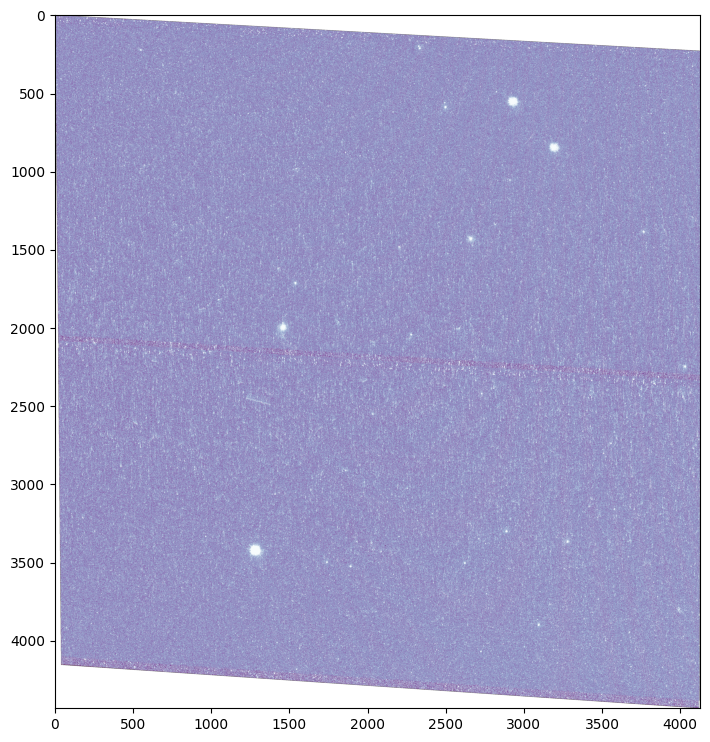

In [16]:
# Create a figure on which to plot our data
fig = plt.figure(0, [9, 9])
ax = fig.add_subplot(111)

# Get the primary data from the first fits file
test_data = hdus[0][1].data

# Automatically scale the brightness based on the data
interval = ZScaleInterval(contrast=0.4)
lims = interval.get_limits(test_data)

# Show our data with the scaling from above
ax.imshow(test_data, vmin=lims[0], vmax=lims[1], cmap='BuPu_r')

In [21]:
hdu_tuples = [(hdu[1].data, hdu[1].header) for hdu in hdus]

In [25]:
wcs, shape = find_optimal_celestial_wcs(hdu_tuples, 
                                        resolution=1*u.arcsec
                                       )

In [26]:
array, footprint = reproject_and_coadd(hdu_tuples,
                                       wcs, shape,
                                       reproject_function=reproject_interp,
                                       match_background=True
                                      )

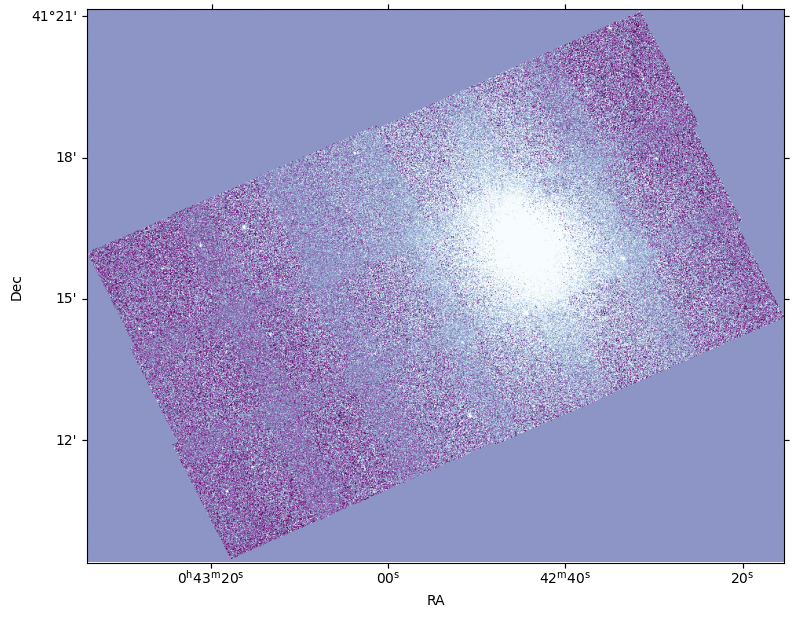

In [27]:
# Create the figure for the new map
fig = plt.figure(0, [9, 9])
ax = fig.add_subplot(111, projection=wcs)

# Automatically scale the brightness
interval = ZScaleInterval(contrast=0.4)
lims = interval.get_limits(array)

# Plot the new map
ax.imshow(array, vmin=lims[0], vmax=lims[1], origin='lower', cmap='BuPu_r')
ax.set_xlabel('RA')
ax.set_ylabel('Dec')